<a href="https://colab.research.google.com/github/Prianka-Mukhopadhyay/city-intelligence-dashboard/blob/main/City_Intelligence_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install osmnx geopandas folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.8 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
#Setting Location
place_name = "Kolkata, India"
#Downloading road network
graph=ox.graph_from_place(place_name, network_type='drive')
print(type(graph))

<class 'networkx.classes.multidigraph.MultiDiGraph'>


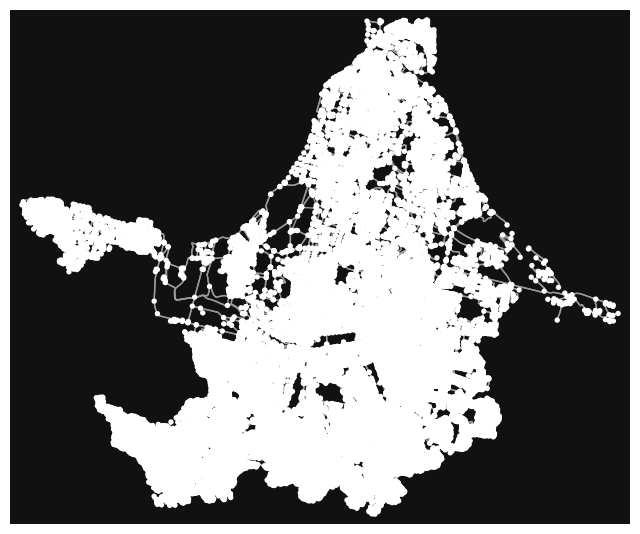

In [ ]:
import matplotlib.pyplot as plt
fig,ax=ox.plot_graph(graph)

In [ ]:
tags={"amenity":"hospital"}
hospitals=ox.features_from_place("Kolkata, India",tags)
print(hospitals.head())

                                     geometry   amenity healthcare  \
element id                                                           
node    1189036467  POINT (88.36002 22.57274)  hospital   hospital   
        1189036837  POINT (88.36144 22.57222)  hospital   hospital   
        1272967205  POINT (88.31633 22.49872)  hospital   hospital   
        1765139008  POINT (88.31217 22.49514)  hospital   hospital   
        2192928421  POINT (88.39382 22.48096)  hospital   hospital   

                                                             name  \
element id                                                          
node    1189036467                                  Eden Hospital   
        1189036837            Calcutta Medical College & Hospital   
        1272967205              Vidyasagar State General Hospital   
        1765139008                                            NaN   
        2192928421  Peerless Hospital and B.K.Roy Research Center   

                         

In [ ]:
import folium
# Get center of map (approx Kolkata center)
center = [22.5726, 88.3639]
#MAP
m=folium.Map(location=center, zoom_start=12)
#adding hospital points
for i,row in hospitals.iterrows():
    if row.geometry.geom_type=="Point":
        lat = row.geometry.y
        lon = row.geometry.x

        folium.CircleMarker(
            location=[lat, lon],
            radius=3,
            color="red",
            fill=True,
            fill_color="red"
        ).add_to(m)

# Show map
m

In [ ]:
# Keep only valid point geometries
hospitals_points = hospitals[hospitals.geometry.geom_type == "Point"]

print(len(hospitals_points))

147


In [ ]:
# Extract hospital coordinates into list
hospital_coords = [(geom.y, geom.x) for geom in hospitals_points.geometry]

print(hospital_coords[:5])

[(22.5727398, 88.3600196), (22.5722242, 88.3614363), (22.4987178, 88.3163322), (22.4951399, 88.3121663), (22.4809641, 88.3938205)]


In [ ]:
import networkx as nx

# Get nodes with coordinates
nodes, edges = ox.graph_to_gdfs(graph)

print(nodes.head())

                   y          x          highway  street_count junction  \
osmid                                                                     
290731701  22.591445  88.393367  traffic_signals             5      NaN   
300544713  22.514426  88.365160              NaN             4      NaN   
300544728  22.513560  88.359289              NaN             3      NaN   
300544741  22.512703  88.351367              NaN             4      NaN   
302472321  22.538150  88.358702              NaN             3      NaN   

          railway                   geometry  
osmid                                         
290731701     NaN  POINT (88.39337 22.59145)  
300544713     NaN  POINT (88.36516 22.51443)  
300544728     NaN  POINT (88.35929 22.51356)  
300544741     NaN   POINT (88.35137 22.5127)  
302472321     NaN   POINT (88.3587 22.53815)  


In [ ]:
# Take 50 sample nodes
sample_nodes = nodes.sample(50, random_state=42)

print(len(sample_nodes))

50


In [ ]:
from geopy.distance import geodesic

def nearest_hospital_distance(point, hospitals):
    min_dist = float('inf')

    for hospital in hospitals:
        dist = geodesic(point, hospital).meters
        if dist < min_dist:
            min_dist = dist

    return min_dist

In [ ]:
distances = []

for idx, row in sample_nodes.iterrows():
    node_point = (row.y, row.x)
    dist = nearest_hospital_distance(node_point, hospital_coords)
    distances.append(dist)

# Add to dataframe
sample_nodes["nearest_hospital_dist"] = distances

print(sample_nodes[["y", "x", "nearest_hospital_dist"]].head())

                    y          x  nearest_hospital_dist
osmid                                                  
1338449274  22.498850  88.377315             892.530405
1327875786  22.517976  88.379602             811.280317
2448423639  22.525605  88.396425             832.601125
1349590527  22.490678  88.347902             487.194814
9568345600  22.477067  88.307473             436.262357


In [ ]:
import folium

# Center map
center = [22.5726, 88.3639]
m2 = folium.Map(location=center, zoom_start=12)

# Function to decide color
def get_color(distance):
    if distance < 500:
        return "green"
    elif distance < 1000:
        return "orange"
    else:
        return "red"

# Add nodes to map
for idx, row in sample_nodes.iterrows():
    lat = row["y"]
    lon = row["x"]
    dist = row["nearest_hospital_dist"]

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color=get_color(dist),
        fill=True,
        fill_color=get_color(dist),
        fill_opacity=0.7
    ).add_to(m2)

# Show map
m2

In [ ]:
import folium

# Center map
center = [22.5726, 88.3639]
m3 = folium.Map(location=center, zoom_start=12)

# Color function
def get_color(distance):
    if distance < 500:
        return "green"
    elif distance < 1000:
        return "orange"
    else:
        return "red"

# Add accessibility nodes
for idx, row in sample_nodes.iterrows():
    lat = row["y"]
    lon = row["x"]
    dist = row["nearest_hospital_dist"]

    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color=get_color(dist),
        fill=True,
        fill_color=get_color(dist),
        fill_opacity=0.7
    ).add_to(m3)

# Add hospitals with names
for idx, row in hospitals_points.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x

    name = row.get("name", "Unknown Hospital")

    folium.Marker(
        location=[lat, lon],
        popup=name,
        icon=folium.Icon(color="blue", icon="plus-sign")
    ).add_to(m3)

# Show map
m3

In [ ]:
import folium

# Center map
center = [22.5726, 88.3639]
m4 = folium.Map(location=center, zoom_start=12)

# Color function
def get_color(distance):
    if distance < 500:
        return "green"
    elif distance < 1000:
        return "orange"
    else:
        return "red"

# Add accessibility nodes with popup
for idx, row in sample_nodes.iterrows():
    lat = row["y"]
    lon = row["x"]
    dist = round(row["nearest_hospital_dist"], 1)

    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color=get_color(dist),
        fill=True,
        fill_color=get_color(dist),
        fill_opacity=0.8,
        popup=f"Distance: {dist} meters"
    ).add_to(m4)

# Show ONLY first 20 hospitals (reduce clutter)
sample_hospitals = hospitals_points.head(20)

for idx, row in sample_hospitals.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    name = row.get("name", "Unknown Hospital")

    folium.Marker(
        location=[lat, lon],
        popup=name,
        icon=folium.Icon(color="blue", icon="plus-sign")
    ).add_to(m4)

# Show map
m4

In [ ]:
from scipy.spatial import KDTree
import numpy as np

# Prepare node coordinates
node_coords = list(zip(nodes["y"], nodes["x"]))

# Build KDTree (fast spatial search)
tree = KDTree(node_coords)

# Function to count nearby nodes
def get_density(point, radius=0.01):
    count = tree.query_ball_point(point, r=radius)
    return len(count)

In [ ]:
density_scores = []

for idx, row in sample_nodes.iterrows():
    point = (row["y"], row["x"])
    density = get_density(point)
    density_scores.append(density)

# Add to dataframe
sample_nodes["density"] = density_scores

print(sample_nodes[["density"]].head())

            density
osmid              
1338449274     1515
1327875786     1838
2448423639      873
1349590527      678
9568345600     1089


In [ ]:
import folium

m5 = folium.Map(location=[22.5726, 88.3639], zoom_start=12)

def get_density_color(d):
    if d < 50:
        return "green"
    elif d < 150:
        return "orange"
    else:
        return "red"

for idx, row in sample_nodes.iterrows():
    lat = row["y"]
    lon = row["x"]
    d = row["density"]

    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color=get_density_color(d),
        fill=True,
        fill_color=get_density_color(d),
        fill_opacity=0.7,
        popup=f"Density: {d}"
    ).add_to(m5)

m5

In [ ]:
import folium

# Create map
m_final = folium.Map(location=[22.5726, 88.3639], zoom_start=12)

# Reuse color logic (accessibility)
def get_access_color(distance):
    if distance < 500:
        return "green"
    elif distance < 1000:
        return "orange"
    else:
        return "red"

# Normalize density for marker size
max_density = sample_nodes["density"].max()

for idx, row in sample_nodes.iterrows():
    lat = row["y"]
    lon = row["x"]

    dist = row["nearest_hospital_dist"]
    density = row["density"]

    # Scale size (important)
    size = (density / max_density) * 10 + 3

    folium.CircleMarker(
        location=[lat, lon],
        radius=size,
        color=get_access_color(dist),
        fill=True,
        fill_color=get_access_color(dist),
        fill_opacity=0.7,
        popup=f"Dist: {round(dist,1)} m | Density: {density}"
    ).add_to(m_final)

# Add limited hospitals again
sample_hospitals = hospitals_points.head(20)

for idx, row in sample_hospitals.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    name = row.get("name", "Unknown Hospital")

    folium.Marker(
        location=[lat, lon],
        popup=name,
        icon=folium.Icon(color="blue", icon="plus-sign")
    ).add_to(m_final)

# Show map
m_final

In [ ]:
# Define threshold (in meters)
threshold = 1000

In [ ]:
underserved = sample_nodes[sample_nodes["nearest_hospital_dist"] > threshold]

print(len(underserved))

14


In [ ]:
underserved_sorted = underserved.sort_values(by="nearest_hospital_dist", ascending=False)

print(underserved_sorted[["y", "x", "nearest_hospital_dist"]].head())

                    y          x  nearest_hospital_dist
osmid                                                  
9544120757  22.536710  88.413604            2518.897958
9559490435  22.475885  88.283740            2444.583839
4204233983  22.525351  88.412508            2388.109893
9544144836  22.552595  88.251150            2129.876027
9544144959  22.550808  88.251898            1978.007365


In [ ]:
percent = (len(underserved) / len(sample_nodes)) * 100
print(f"{percent:.2f}% of sampled locations are underserved")

28.00% of sampled locations are underserved


In [ ]:
print(underserved_sorted[["y", "x", "nearest_hospital_dist"]].head())

                    y          x  nearest_hospital_dist
osmid                                                  
9544120757  22.536710  88.413604            2518.897958
9559490435  22.475885  88.283740            2444.583839
4204233983  22.525351  88.412508            2388.109893
9544144836  22.552595  88.251150            2129.876027
9544144959  22.550808  88.251898            1978.007365
